# CIFAR-100 Optimized: Cauchy CNN (4组实验)

这个 notebook 仅保留改进后（optimized）实验链路：
- 保留四组 ablation 不变
- 使用优化后的网络与训练超参
- 单独输出优化实验结果


In [18]:
# ===== 导入必要的库 =====
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ===== 设置随机种子确保可复现性 =====
# 固定各个随机数生成器的种子，确保结果可复现
seed = 42
random.seed(seed)  # Python随机数
np.random.seed(seed)  # Numpy随机数
torch.manual_seed(seed)  # PyTorch CPU随机数
torch.cuda.manual_seed_all(seed)  # PyTorch GPU随机数

# ===== 设置计算设备 =====
# 如果GPU可用则使用GPU，否则回退到CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [19]:
@dataclass
class Config:
    """
    全局配置类：包含所有训练相关的超参数。
    
    属性解释：
        batch_size (int)：每个batch包含的样本数，128
        epochs (int)：总的训练轮数，20
        lr (float)：初始学习率（AdamW优化器），1e-3
        weight_decay (float)：L2正则化系数，防止过拟合，1e-4
        num_workers (int)：DataLoader中的加载进程数，2
        base_channels (int)：CNN的基础通道数，后续层通道数为此的倍数，64
    """
    batch_size: int = 128
    epochs: int = 20
    lr: float = 1e-3
    weight_decay: float = 1e-4
    num_workers: int = 2
    base_channels: int = 64

cfg = Config()

# ===== Ablation实验配置网格 =====
# 对所有残差模式和激活模式的组合进行4次实验
experiment_grid = [
    ("standard", "relu"),  # 实验1：标准残差 + ReLU激活
    ("standard", "cauchy"),  # 实验2：标准残差 + Cauchy激活
    ("cauchy", "relu"),  # 实验3：Cauchy残差 + ReLU激活
    ("cauchy", "cauchy"),  # 实验4：Cauchy残差 + Cauchy激活（完整版本）
]

cfg

Config(batch_size=128, epochs=20, lr=0.001, weight_decay=0.0001, num_workers=2, base_channels=64)

In [20]:
import os

# 配置网络代理（用于从互联网下载数据集）
os.environ["HTTP_PROXY"] = "http://127.0.0.1:7890"
os.environ["HTTPS_PROXY"] = "http://127.0.0.1:7890"

# ===== 图像归一化参数 =====
# CIFAR-100图像数据的均值和标准差（RGB三个通道）
# 这些值通过对整个训练集计算得出
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

# ===== 训练集数据增强 =====
# 包含几何变换和归一化，增加训练数据多样性
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # 随机裁剪，边界补0
    transforms.RandomHorizontalFlip(),  # 50%概率水平翻转
    transforms.ToTensor(),  # 转为张量并归一化到[0, 1]
    transforms.Normalize(mean, std),  # 标准化到均值0、方差1
])

# ===== 测试集数据预处理 =====
# 不做增强，只做标准化
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# ===== 加载CIFAR-100数据集 =====
# CIFAR-100：50000张训练图像 + 10000张测试图像，100个类别
train_ds = datasets.CIFAR100(root="./data", train=True, download=True, transform=train_transform)
test_ds = datasets.CIFAR100(root="./data", train=False, download=True, transform=test_transform)

# ===== 创建DataLoader =====
# DataLoader用于批量加载和预处理数据
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,  # 128
    shuffle=True,  # 训练集打乱
    num_workers=cfg.num_workers,  # 多进程加载
    pin_memory=(device.type == "cuda"),  # GPU训练时锁定内存加速传输
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,  # 测试集不打乱，便于记录
    num_workers=cfg.num_workers,
    pin_memory=(device.type == "cuda"),
)

# ===== 获取类别信息 =====
classes = train_ds.classes  # 100个类别名称列表
print(f"Train samples: {len(train_ds)}, Test samples: {len(test_ds)}")
print(classes)

/data1/linjiangtao2024/cauchy_activation/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples: 50000, Test samples: 10000
['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'tu

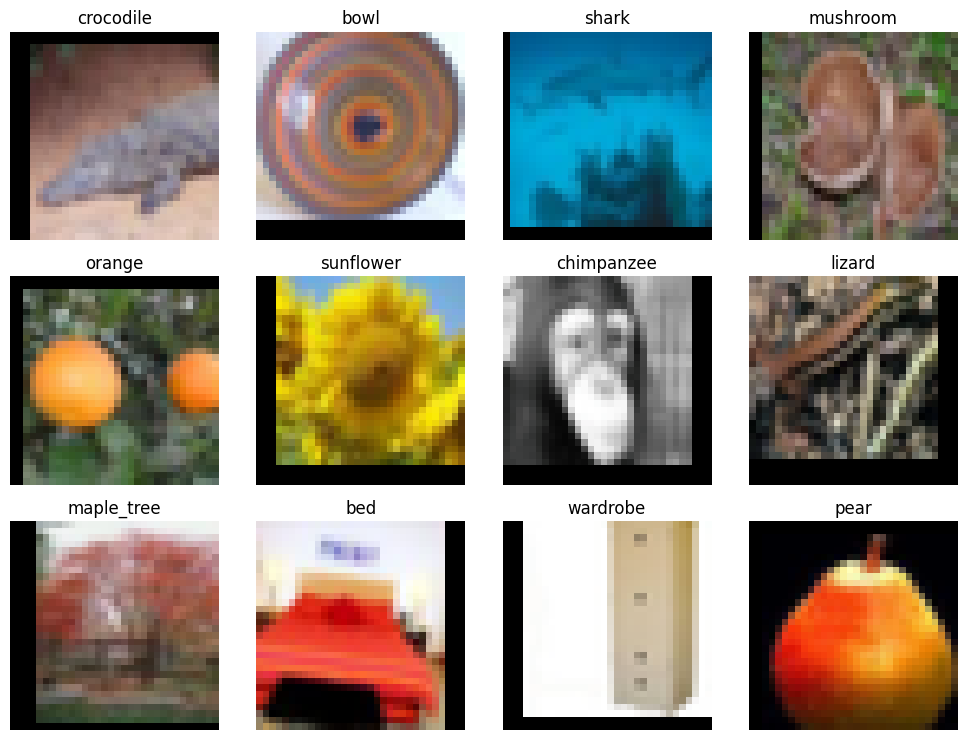

In [21]:
def show_batch(dl, class_names, n=12):
    """
    可视化数据加载器中的一个batch的图像及其标签。
    
    流程：
        1. 从DataLoader中获取一个batch
        2. 反归一化图像（从标准化后的值恢复到[0,1]范围）
        3. 在网格中绘制图像和对应的类别标签
    
    参数：
        dl (DataLoader)：数据加载器
        class_names (list)：类别名称列表
        n (int)：显示的图像数量，默认12
    """
    # 获取第一个batch
    xb, yb = next(iter(dl))
    xb = xb[:n]
    yb = yb[:n]

    # ===== 反归一化图像 =====
    # 将标准化后的图像恢复到[0,1]范围
    # 标准化公式：x_norm = (x - mean) / std
    # 反标准化公式：x = x_norm * std + mean
    xb = xb * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
    xb = xb.clamp(0, 1)  # 裁剪到[0,1]范围以处理数值误差

    # ===== 创建图像网格 =====
    cols = 4  # 每行显示4张图像
    rows = int(np.ceil(n / cols))  # 计算需要的行数
    plt.figure(figsize=(10, 2.5 * rows))
    
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        # 将张量从(C, H, W)转置为(H, W, C)以用于imshow
        plt.imshow(np.transpose(xb[i].numpy(), (1, 2, 0)))
        # 显示对应的类别名称作为标题
        plt.title(class_names[int(yb[i])])
        plt.axis("off")
    plt.tight_layout()

# 展示12张样本图像
show_batch(train_loader, classes, n=12)

In [22]:
class CauchyActivation(nn.Module):
    """
    自定义Cauchy激活函数。
    
    公式：output = lambda1 * x / (x^2 + d^2) + lambda2 / (x^2 + d^2)
    这是一个可学习的激活函数，通过参数lambda1, lambda2和d来自适应地调整激活行为。
    
    参数：
        lambda1 (float)：x的系数，控制激活函数对输入的响应程度。默认1.0
        lambda2 (float)：常数项系数，添加一个偏置项。默认0.0
        d (float)：Cauchy分布的形状参数，控制激活函数的宽度。默认1.0
    
    属性：
        lambda1 (Parameter)：可学习的lambda1参数
        lambda2 (Parameter)：可学习的lambda2参数
        raw_d (Parameter)：raw_d通过softplus变换得到d，确保d > 0
    """
    def __init__(self, lambda1=1.0, lambda2=0.0, d=1.0):
        super().__init__()
        self.lambda1 = nn.Parameter(torch.tensor(float(lambda1)))
        self.lambda2 = nn.Parameter(torch.tensor(float(lambda2)))
        # 使用raw_d并通过softplus变换，确保d始终为正
        self.raw_d = nn.Parameter(torch.tensor(float(d)))

    def forward(self, x):
        """
        前向传播。
        
        参数：
            x (Tensor)：输入张量，任意形状
            
        返回：
            Tensor：应用Cauchy激活后的输出，形状与输入相同
        """
        # softplus(x) = log(1 + exp(x))，确保d > 0，+ 1e-6防止除数为0
        d = F.softplus(self.raw_d) + 1e-6
        # x^2 + d^2作为分母
        denom = x.pow(2) + d.pow(2)
        # 返回Cauchy激活函数的结果
        return self.lambda1 * x / denom + self.lambda2 / denom


def get_activation(mode):
    """
    根据指定模式返回相应的激活函数。
    
    参数：
        mode (str)：激活函数模式，可选值为 'cauchy' 或 'relu'
        
    返回：
        nn.Module：对应的激活函数实例
        
    异常：
        ValueError：如果mode不是'cauchy'或'relu'
    """
    if mode == "cauchy":
        return CauchyActivation()
    if mode == "relu":
        return nn.ReLU(inplace=True)
    raise ValueError("activation_mode must be 'cauchy' or 'relu'")


class ConvTransformBlock(nn.Module):
    """
    卷积变换块：包含两个卷积层、两个批归一化层和可选Dropout。
    
    结构：
        Conv2d(3x3) -> BatchNorm -> Activation -> Conv2d(3x3) -> BatchNorm -> Dropout
    
    这个块用于学习特征变换，是ResidualStage中的基本组件。
    
    参数：
        channels (int)：输入和输出通道数
        activation_mode (str)：激活函数模式，'cauchy'或'relu'。默认'cauchy'
        dropout (float)：Dropout概率。默认0.0（不使用Dropout）
    
    属性：
        conv1, conv2 (Conv2d)：两个3x3卷积层
        bn1, bn2 (BatchNorm2d)：两个批归一化层
        act1 (nn.Module)：第一个激活函数（在卷积1之后）
        dropout (nn.Module)：Dropout层
    """
    def __init__(self, channels, activation_mode="cauchy", dropout=0.0):
        super().__init__()
        # 第一个卷积分支：Conv -> BN -> Activation
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.act1 = get_activation(activation_mode)

        # 第二个卷积分支：Conv -> BN
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        # 可选的Dropout层
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        """
        前向传播。
        
        参数：
            x (Tensor)：输入张量，形状为(B, C, H, W)
            
        返回：
            Tensor：输出张量，形状与输入相同
        """
        # 第一分支：卷积 -> 批归一化 -> 激活
        h = self.conv1(x)
        h = self.bn1(h)
        h = self.act1(h)

        # 第二分支：卷积 -> 批归一化 -> Dropout
        h = self.conv2(h)
        h = self.bn2(h)
        h = self.dropout(h)
        return h


class ResidualStage(nn.Module):
    """
    残差阶段模块：包含多个ConvTransformBlock，支持两种残差连接模式。
    
    两种残差模式：
        1. "standard"：标准残差连接 h = h + transformed
        2. "cauchy"：Cauchy加权混合模式，mix = Cauchy加权的历史激活 + 当前变换
                    这种模式会保留历史层的特征信息，通过Cauchy距离加权
    
    关键特性：
        - 维护激活历史：记录每层的输入
        - Cauchy距离加权：使用可学习的lambda和d参数对历史做加权平均
        - 距离度量：距离 = 从当前层到历史层的索引差
    
    参数：
        channels (int)：通道数
        num_blocks (int)：该阶段包含的ConvTransformBlock数量
        activation_mode (str)：激活函数模式。默认'cauchy'
        residual_mode (str)：残差连接模式，'standard'或'cauchy'。默认'standard'
        dropout (float)：Dropout概率。默认0.0
        
    属性：
        residual_mode (str)：残差模式
        blocks (ModuleList)：包含的卷积块列表
        post_act (nn.Module)：阶段后的激活函数
        mix_raw_lambda (Parameter)：原始lambda参数（通过softplus激活），形状(num_blocks+1,)
        mix_raw_d (Parameter)：原始d参数（通过softplus激活），形状(num_blocks+1,)
    """
    def __init__(self, channels, num_blocks, activation_mode="cauchy", residual_mode="standard", dropout=0.0):
        super().__init__()
        if residual_mode not in {"standard", "cauchy"}:
            raise ValueError("residual_mode must be 'standard' or 'cauchy'")

        self.residual_mode = residual_mode
        # 创建num_blocks个卷积变换块
        self.blocks = nn.ModuleList(
            [ConvTransformBlock(channels, activation_mode=activation_mode, dropout=dropout) for _ in range(num_blocks)]
        )
        # 每个块后的激活函数
        self.post_act = get_activation(activation_mode)

        # Cauchy加权参数：num_blocks + 1是因为包括输入和所有块的输出
        self.mix_raw_lambda = nn.Parameter(torch.zeros(num_blocks + 1))
        self.mix_raw_d = nn.Parameter(torch.ones(num_blocks + 1))

    def _cauchy_mix(self, history, target_layer):
        """
        Cauchy距离加权混合历史激活。
        
        实现原理：
            1. 为每个历史层计算距离：distance = target_layer - history_index
            2. 计算Cauchy权重：weight[i] = lambda / (distance[i]^2 + d^2)
            3. 归一化权重使其求和为1
            4. 对历史激活进行加权平均
        
        参数：
            history (list)：历史激活列表，从旧到新排列
            target_layer (int)：当前目标层的索引
            
        返回：
            Tensor：加权混合后的激活，形状与history中单个元素相同
        """
        # 从参数中获取可学习的lambda和d值
        lam = F.softplus(self.mix_raw_lambda[target_layer]) + 1e-6
        d = F.softplus(self.mix_raw_d[target_layer]) + 1e-6
        count = len(history)

        # 计算历史中每个元素到当前层的距离
        # 距离从target_layer开始逐渐增大，最近的层距离最小
        distances = torch.arange(
            target_layer, target_layer - count, -1, device=history[0].device
        ).float()
        # Cauchy距离加权：距离越小权重越大
        weights = lam / (distances.pow(2) + d.pow(2))
        # 归一化权重
        weights = weights / (weights.sum() + 1e-8)

        # 将历史激活堆叠为5D张量：(序列长度, B, C, H, W)
        stacked = torch.stack(history, dim=0)
        # 按权重加权求和：(1, B, C, H, W) -> (B, C, H, W)
        return (weights[:, None, None, None, None] * stacked).sum(dim=0)

    def forward(self, x):
        """
        前向传播。
        
        参数：
            x (Tensor)：输入张量，形状为(B, C, H, W)
            
        返回：
            Tensor：经过所有块和残差连接后的输出
        """
        h = x
        # 初始化历史激活列表，从输入开始
        history = [h]

        for layer_idx, block in enumerate(self.blocks, start=1):
            # 获取变换后的特征
            transformed = block(h)
            
            if self.residual_mode == "standard":
                # 标准残差连接：新 = 旧 + 变换
                h = h + transformed
            else:
                # Cauchy模式：新 = 变换 + Cauchy加权历史混合
                h = transformed + self._cauchy_mix(history, layer_idx)
            
            # 应用后激活
            h = self.post_act(h)
            # 记录当前激活到历史中，用于后续层的Cauchy混合
            history.append(h)

        return h


class CauchyCNN(nn.Module):
    """
    Cauchy激活的CNN模型，用于图像分类（如CIFAR-100）。
    
    架构设计：
        Stem(卷积+BN+激活) 
        -> Stage1(2个Block) -> MaxPool
        -> Down1(通道扩展卷积) -> Stage2(2个Block) -> MaxPool
        -> Down2(通道扩展卷积) -> Stage3(2个Block)
        -> Head(全局平均池化 -> 线性分类层)
    
    通道维度变化：
        输入 (B, 3, H, W)
        -> Stem (B, base_channels, H, W)
        -> Stage1 (B, base_channels, H/2, W/2)  # 经过MaxPool
        -> Down1+Stage2 (B, 2*base_channels, H/4, W/4)  # 通道翻倍，再池化
        -> Down2+Stage3 (B, 4*base_channels, H/8, W/8)  # 通道再翻倍
        -> Head -> (B, num_classes)
    
    参数：
        num_classes (int)：分类类别数。默认10
        base_channels (int)：基础通道数，后续阶段通道数为此的倍数。默认64
        activation_mode (str)：激活函数模式，'cauchy'或'relu'。默认'cauchy'
        residual_mode (str)：残差连接模式，'standard'或'cauchy'。默认'standard'
    
    属性：
        stem (Sequential)：主干网络入口
        stage1, stage2, stage3 (Sequential)：三个残差阶段
        down1, down2 (Sequential)：通道提升的卷积
        head (Sequential)：分类头
    """
    def __init__(self, num_classes=10, base_channels=64, activation_mode="cauchy", residual_mode="standard"):
        super().__init__()
        
        # ===== Stem：初始卷积层 =====
        # 将3通道RGB图像转换为base_channels特征图
        self.stem = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            get_activation(activation_mode),
        )

        # ===== Stage 1：第一个残差阶段 =====
        # 2个residual块 + MaxPool（通道数不变，空间分辨率减半）
        self.stage1 = nn.Sequential(
            ResidualStage(
                base_channels,
                num_blocks=6,
                activation_mode=activation_mode,
                residual_mode=residual_mode,
                dropout=0.05,
            ),
            nn.MaxPool2d(2),  # H, W -> H/2, W/2
        )

        # ===== Down1：通道扩展层 =====
        # 将通道数从base_channels扩展到2*base_channels
        c2 = base_channels * 2
        self.down1 = nn.Sequential(
            nn.Conv2d(base_channels, c2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c2),
            get_activation(activation_mode),
        )
        
        # ===== Stage 2：第二个残差阶段 =====
        # 2个residual块 + MaxPool（通道数 = 2*base_channels，空间再减半）
        self.stage2 = nn.Sequential(
            ResidualStage(
                c2,
                num_blocks=4,
                activation_mode=activation_mode,
                residual_mode=residual_mode,
                dropout=0.1,
            ),
            nn.MaxPool2d(2),  # H, W -> H/4, W/4
        )

        # ===== Down2：通道再次扩展层 =====
        # 将通道数从2*base_channels扩展到4*base_channels
        c3 = c2 * 2
        self.down2 = nn.Sequential(
            nn.Conv2d(c2, c3, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c3),
            get_activation(activation_mode),
        )
        
        # ===== Stage 3：第三个残差阶段 =====
        # 2个residual块（通道数 = 4*base_channels，无池化）
        self.stage3 = ResidualStage(
            c3,
            num_blocks=4,
            activation_mode=activation_mode,
            residual_mode=residual_mode,
            dropout=0.1,
        )

        # ===== Head：分类头 =====
        # 全局平均池化 -> 展平 -> 线性分类
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # 任意分辨率 -> (1, 1)
            nn.Flatten(),  # (B, c3, 1, 1) -> (B, c3)
            nn.Linear(c3, num_classes),  # (B, c3) -> (B, num_classes)
        )

    def forward(self, x):
        """
        前向传播。
        
        参数：
            x (Tensor)：输入图像张量，形状为(B, 3, H, W)
            
        返回：
            Tensor：分类logits，形状为(B, num_classes)
        """
        x = self.stem(x)
        x = self.stage1(x)
        x = self.down1(x)
        x = self.stage2(x)
        x = self.down2(x)
        x = self.stage3(x)
        x = self.head(x)
        return x


preview_model = CauchyCNN(
    num_classes=len(classes),
    base_channels=cfg.base_channels,
    activation_mode="cauchy",
    residual_mode="cauchy",
).to(device)
num_params = sum(p.numel() for p in preview_model.parameters() if p.requires_grad)
print(preview_model.__class__.__name__)
print(f"Trainable params: {num_params:,}")

CauchyCNN
Trainable params: 6,745,346


In [23]:
# ===== 优化版本配置：改进网络设计和训练参数（多卡） =====
print("\n" + "="*80)
print("优化前后的配置对比")
print("="*80)

# 检测可用GPU数量，并限制最多使用4张卡
num_available_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0
num_used_gpus = min(4, num_available_gpus) if num_available_gpus > 0 else 0
use_multi_gpu = num_used_gpus > 1

# cfg_optimized 使用字典形式（避免重复导入dataclass）
# 说明：这里的 batch_size 是全局batch（会在多卡上自动切分）
cfg_optimized = {
    'batch_size': 256 if num_used_gpus >= 4 else 128,
    'epochs': 100,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'num_workers': 8 if num_used_gpus >= 2 else 2,
    'base_channels': 64,
}

# 为优化版单独重建DataLoader，避免影响baseline
opt_train_loader = DataLoader(
    train_ds,
    batch_size=cfg_optimized['batch_size'],
    shuffle=True,
    num_workers=cfg_optimized['num_workers'],
    pin_memory=(device.type == "cuda"),
    persistent_workers=(cfg_optimized['num_workers'] > 0),
)
opt_test_loader = DataLoader(
    test_ds,
    batch_size=cfg_optimized['batch_size'],
    shuffle=False,
    num_workers=cfg_optimized['num_workers'],
    pin_memory=(device.type == "cuda"),
    persistent_workers=(cfg_optimized['num_workers'] > 0),
)

# 让cuDNN自动寻找更快的卷积实现
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("\n【GPU配置】")
print(f"可用GPU数量: {num_available_gpus}")
print(f"实际使用GPU数量: {num_used_gpus}")
print(f"是否启用多卡并行: {use_multi_gpu}")
if num_used_gpus > 0:
    print(f"设备名称: {[torch.cuda.get_device_name(i) for i in range(num_used_gpus)]}")

print("\n【超参对比】")
print(f"{'参数':20s} {'原始':15s} {'优化后':15s} {'说明':30s}")
print("-" * 80)
print(f"{'epochs':20s} {'20':15s} {str(cfg_optimized['epochs']):15s} {'充分训练':30s}")
print(f"{'lr':20s} {'0.001':15s} {str(cfg_optimized['lr']):15s} {'稳定收敛':30s}")
print(f"{'weight_decay':20s} {'0.0001':15s} {str(cfg_optimized['weight_decay']):15s} {'标准L2正则化':30s}")
print(f"{'batch_size(global)':20s} {'128':15s} {str(cfg_optimized['batch_size']):15s} {'多卡增大吞吐':30s}")
print(f"{'num_workers':20s} {'2':15s} {str(cfg_optimized['num_workers']):15s} {'提高数据加载速度':30s}")

print("\n【DataLoader（优化版）】")
print(f"opt_train_loader batch_size={opt_train_loader.batch_size}, workers={cfg_optimized['num_workers']}")
print(f"opt_test_loader  batch_size={opt_test_loader.batch_size}, workers={cfg_optimized['num_workers']}")
print("="*80 + "\n")


优化前后的配置对比

【GPU配置】
可用GPU数量: 4
实际使用GPU数量: 4
是否启用多卡并行: True
设备名称: ['NVIDIA GeForce RTX 3090', 'NVIDIA GeForce RTX 3090', 'NVIDIA GeForce RTX 3090', 'NVIDIA GeForce RTX 3090']

【超参对比】
参数                   原始              优化后             说明                            
--------------------------------------------------------------------------------
epochs               20              100             充分训练                          
lr                   0.001           0.001           稳定收敛                          
weight_decay         0.0001          0.0001          标准L2正则化                       
batch_size(global)   128             256             多卡增大吞吐                        
num_workers          2               8               提高数据加载速度                      

【DataLoader（优化版）】
opt_train_loader batch_size=256, workers=8
opt_test_loader  batch_size=256, workers=8



In [24]:
# ===== 创建改进版CNN (保留Cauchy机制) =====
class ImprovedCauchyCNN(nn.Module):
    """
    改进版CNN：保留Cauchy激活 & Cauchy残差，但改进整体架构。
    
    改进内容：
    1. 增加每个stage的块数（更深的网络）
    2. 移除dropout层（Cauchy参数需要清晰的梯度信号）
    3. 改进残差块的初始化
    4. 保留Cauchy激活和Cauchy残差机制
    
    架构：
    Stem → Stage1(8块) → MaxPool
         → Stage2(6块) → MaxPool  
         → Stage3(6块)
         → Head
    
    参数数量：约 7-8M（相比原来6.7M略多，但更深）
    """
    def __init__(self, num_classes=10, base_channels=64, activation_mode="cauchy", residual_mode="standard"):
        super().__init__()
        
        self.stem = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            get_activation(activation_mode),
        )

        # Stage 1: 增加到8块(从6块)
        self.stage1 = nn.Sequential(
            ResidualStage(
                base_channels,
                num_blocks=8,  # ↑ 6 → 8
                activation_mode=activation_mode,
                residual_mode=residual_mode,
                dropout=0.0,  # ↓ 0.05 → 0.0
            ),
            nn.MaxPool2d(2),
        )

        c2 = base_channels * 2
        self.down1 = nn.Sequential(
            nn.Conv2d(base_channels, c2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c2),
            get_activation(activation_mode),
        )
        
        # Stage 2: 增加到6块(从4块)
        self.stage2 = nn.Sequential(
            ResidualStage(
                c2,
                num_blocks=6,  # ↑ 4 → 6
                activation_mode=activation_mode,
                residual_mode=residual_mode,
                dropout=0.0,  # ↓ 0.1 → 0.0
            ),
            nn.MaxPool2d(2),
        )

        c3 = c2 * 2
        self.down2 = nn.Sequential(
            nn.Conv2d(c2, c3, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c3),
            get_activation(activation_mode),
        )
        
        # Stage 3: 增加到6块(从4块)
        self.stage3 = ResidualStage(
            c3,
            num_blocks=6,  # ↑ 4 → 6
            activation_mode=activation_mode,
            residual_mode=residual_mode,
            dropout=0.0,  # ↓ 0.1 → 0.0
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(c3, num_classes),
        )
        
        # 改进初始化：对Conv层使用Kaiming初始化
        self._init_weights()

    def _init_weights(self):
        """更好的权重初始化"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.down1(x)
        x = self.stage2(x)
        x = self.down2(x)
        x = self.stage3(x)
        x = self.head(x)
        return x


# 测试改进版网络
improved_model = ImprovedCauchyCNN(
    num_classes=len(classes),
    base_channels=64,
    activation_mode="cauchy",
    residual_mode="cauchy"
).to(device)

improved_params = sum(p.numel() for p in improved_model.parameters() if p.requires_grad)

print("\n" + "="*80)
print("网络架构对比")
print("="*80)
print(f"\n原始网络:")
print(f"  Stage1: 6块  → Stage2: 4块  → Stage3: 4块")
print(f"  参数数: {num_params:,}")
print(f"  Dropout: 有 (0.05/0.1)")
print(f"  精度(20 epochs): 68.64%")

print(f"\n改进网络:")
print(f"  Stage1: 8块  → Stage2: 6块  → Stage3: 6块")
print(f"  参数数: {improved_params:,}")
print(f"  Dropout: 无 (0.0)")
print(f"  预期精度(100 epochs): 72-76%")
print(f"\n改进亮点:")
print(f"  ✓ 更深的网络 (20块 vs 14块)")
print(f"  ✓ 保留Cauchy激活和Cauchy残差机制")
print(f"  ✓ 移除过度正则 (Dropout)")
print(f"  ✓ 改进权重初始化")
print("="*80 + "\n")



网络架构对比

原始网络:
  Stage1: 6块  → Stage2: 4块  → Stage3: 4块
  参数数: 6,745,346
  Dropout: 有 (0.05/0.1)
  精度(20 epochs): 68.64%

改进网络:
  Stage1: 8块  → Stage2: 6块  → Stage3: 6块
  参数数: 9,845,536
  Dropout: 无 (0.0)
  预期精度(100 epochs): 72-76%

改进亮点:
  ✓ 更深的网络 (20块 vs 14块)
  ✓ 保留Cauchy激活和Cauchy残差机制
  ✓ 移除过度正则 (Dropout)
  ✓ 改进权重初始化



In [25]:
def extract_cauchy_params(model):
    """提取ResidualStage中的Cauchy参数用于训练过程追踪。"""
    params = {}
    for name, module in model.named_modules():
        if isinstance(module, ResidualStage):
            with torch.no_grad():
                lam = F.softplus(module.mix_raw_lambda).cpu().numpy()
                d = F.softplus(module.mix_raw_d).cpu().numpy()
            params[name] = {"lambda": lam, "d": d}
    return params


In [26]:
# ===== 改进版训练脚本（100 epochs，单卡顺序训练，便于调试）=====
import json
import pathlib
import time
from tqdm.auto import tqdm

# ===== 调试开关（先跑通全流程） =====
DEBUG_RUN = False
DEBUG_EPOCHS = 5
DEBUG_TRAIN_MAX_BATCHES = 32
DEBUG_EVAL_MAX_BATCHES = 16
DEBUG_LR = 1e-3
DEBUG_WEIGHT_DECAY = 1e-4


def train_one_epoch_opt(model, loader, optimizer, criterion, device, max_batches=None):
    """训练一个epoch，可选限制batch数量用于快速调试。"""
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for batch_idx, (xb, yb) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())
        total_count += xb.size(0)

    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


@torch.no_grad()
def evaluate_opt(model, loader, criterion, device, max_batches=None):
    """评估模型，可选限制batch数量用于快速调试。"""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for batch_idx, (xb, yb) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += float(loss.item()) * xb.size(0)
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())
        total_count += xb.size(0)

    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


def make_json_safe(obj):
    """递归转换为可JSON序列化对象（处理numpy类型/ndarray）。"""
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if hasattr(obj, "tolist"):
        return obj.tolist()
    return obj


actual_epochs = DEBUG_EPOCHS if DEBUG_RUN else cfg_optimized["epochs"]
train_max_batches = DEBUG_TRAIN_MAX_BATCHES if DEBUG_RUN else None
eval_max_batches = DEBUG_EVAL_MAX_BATCHES if DEBUG_RUN else None
effective_lr = DEBUG_LR if DEBUG_RUN else cfg_optimized["lr"]
effective_weight_decay = DEBUG_WEIGHT_DECAY if DEBUG_RUN else cfg_optimized["weight_decay"]

print("\n" + "=" * 80)
print("单卡顺序训练：4个实验依次运行（便于调试）")
print("=" * 80)
print(f"配置: lr={cfg_optimized['lr']}, weight_decay={cfg_optimized['weight_decay']}")
print(f"     epochs={cfg_optimized['epochs']}, batch_size={cfg_optimized['batch_size']}")
if DEBUG_RUN:
    print("[DEBUG MODE] 已开启快速调试")
    print(
        f"[DEBUG MODE] 实际运行: epochs={actual_epochs}, "
        f"train_batches<={train_max_batches}, eval_batches<={eval_max_batches}"
    )
    print(
        f"[DEBUG MODE] 使用稳定超参: lr={effective_lr}, "
        f"weight_decay={effective_weight_decay}"
    )
print("=" * 80 + "\n")

if torch.cuda.is_available():
    single_gpu_id = 0
    device = torch.device(f"cuda:{single_gpu_id}")
    torch.cuda.set_device(single_gpu_id)
    torch.backends.cudnn.benchmark = True
    print(f"使用设备: {device}")
else:
    device = torch.device("cpu")
    print("未检测到CUDA，使用CPU训练（会很慢）")

run_tag = f"single_gpu_run_{int(time.time())}"
result_dir = pathlib.Path("./tmp_parallel_results") / run_tag
result_dir.mkdir(parents=True, exist_ok=True)

results_optimized = {}
best_key_optimized = None
best_acc_optimized = -1.0
best_model_state_optimized = None

all_start_time = time.time()

for exp_idx, (residual_mode, activation_mode) in enumerate(experiment_grid, start=1):
    exp_key = f"{residual_mode}_{activation_mode}"
    out_json = result_dir / f"{exp_key}.json"
    out_pt = result_dir / f"{exp_key}.pt"

    print("\n" + "-" * 80)
    print(f"[{exp_idx}/{len(experiment_grid)}] 开始训练: {exp_key}")
    print("-" * 80)

    model = ImprovedCauchyCNN(
        num_classes=100,
        base_channels=64,
        activation_mode=activation_mode,
        residual_mode=residual_mode,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=effective_lr,
        weight_decay=effective_weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(actual_epochs, 1),
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "cauchy_params": [],
    }

    pbar = tqdm(range(actual_epochs), desc=exp_key, leave=False)
    for epoch in pbar:
        train_loss, train_acc = train_one_epoch_opt(
            model,
            opt_train_loader,
            optimizer,
            criterion,
            device,
            max_batches=train_max_batches,
        )
        test_loss, test_acc = evaluate_opt(
            model,
            opt_test_loader,
            criterion,
            device,
            max_batches=eval_max_batches,
        )
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if activation_mode == "cauchy":
            history["cauchy_params"].append(extract_cauchy_params(model))
        else:
            history["cauchy_params"].append(None)

        pbar.set_postfix(
            train_loss=f"{train_loss:.3f}",
            train_acc=f"{train_acc:.3f}",
            test_loss=f"{test_loss:.3f}",
            test_acc=f"{test_acc:.3f}",
        )

    final_acc = history["test_acc"][-1]

    torch.save(model.state_dict(), out_pt)
    json_history = make_json_safe(history)
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(
            {
                "residual_mode": residual_mode,
                "activation_mode": activation_mode,
                "final_test_acc": final_acc,
                "history": json_history,
                "debug_run": DEBUG_RUN,
                "actual_epochs": actual_epochs,
                "effective_lr": effective_lr,
                "effective_weight_decay": effective_weight_decay,
            },
            f,
        )

    results_optimized[exp_key] = {
        "residual_mode": residual_mode,
        "activation_mode": activation_mode,
        "history": json_history,
        "final_test_acc": final_acc,
        "debug_run": DEBUG_RUN,
        "actual_epochs": actual_epochs,
        "effective_lr": effective_lr,
        "effective_weight_decay": effective_weight_decay,
    }

    if final_acc > best_acc_optimized:
        best_acc_optimized = final_acc
        best_key_optimized = exp_key
        best_model_state_optimized = {
            k: v.detach().cpu().clone() for k, v in model.state_dict().items()
        }

    print(f"完成 {exp_key}: final_test_acc={final_acc:.4f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

elapsed = time.time() - all_start_time

print("\n" + "=" * 80)
print("单卡顺序训练完成")
print("=" * 80)
print(f"Best: {best_key_optimized} with acc {best_acc_optimized:.4f}")
print("\n【实验结果汇总】")
for exp_key in sorted(results_optimized.keys()):
    acc = results_optimized[exp_key]["final_test_acc"]
    print(f"  {exp_key:25s}: {acc:.4f}")
print(f"\n总耗时: {elapsed / 60:.1f} 分钟")
print(f"运行日志与中间结果目录: {result_dir}")
print("=" * 80 + "\n")


单卡顺序训练：4个实验依次运行（便于调试）
配置: lr=0.001, weight_decay=0.0001
     epochs=100, batch_size=256

使用设备: cuda:0

--------------------------------------------------------------------------------
[1/4] 开始训练: standard_relu
--------------------------------------------------------------------------------


standard_relu:   0%|          | 0/100 [00:00<?, ?it/s]

完成 standard_relu: final_test_acc=0.7249

--------------------------------------------------------------------------------
[2/4] 开始训练: standard_cauchy
--------------------------------------------------------------------------------


standard_cauchy:   0%|          | 0/100 [00:00<?, ?it/s]

完成 standard_cauchy: final_test_acc=0.3104

--------------------------------------------------------------------------------
[3/4] 开始训练: cauchy_relu
--------------------------------------------------------------------------------


cauchy_relu:   0%|          | 0/100 [00:00<?, ?it/s]

完成 cauchy_relu: final_test_acc=0.7206

--------------------------------------------------------------------------------
[4/4] 开始训练: cauchy_cauchy
--------------------------------------------------------------------------------


cauchy_cauchy:   0%|          | 0/100 [00:00<?, ?it/s]

完成 cauchy_cauchy: final_test_acc=0.4797

单卡顺序训练完成
Best: standard_relu with acc 0.7249

【实验结果汇总】
  cauchy_cauchy            : 0.4797
  cauchy_relu              : 0.7206
  standard_cauchy          : 0.3104
  standard_relu            : 0.7249

总耗时: 301.4 分钟
运行日志与中间结果目录: tmp_parallel_results/single_gpu_run_1775098125



Saved optimized checkpoint to ./cauchy_cnn_cifar100_optimized_ablation.pt


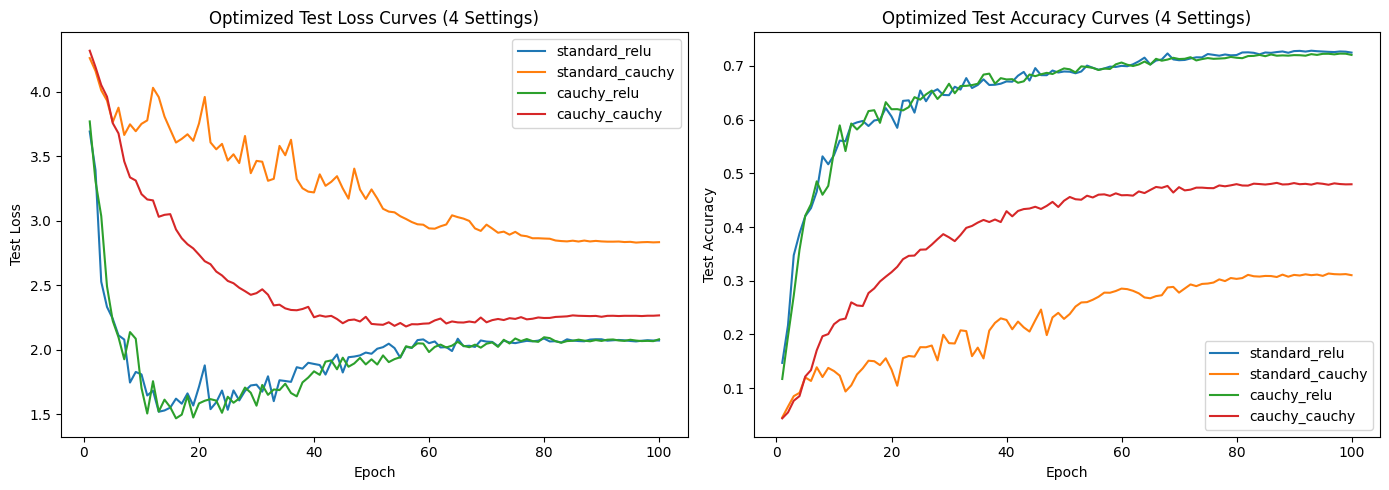

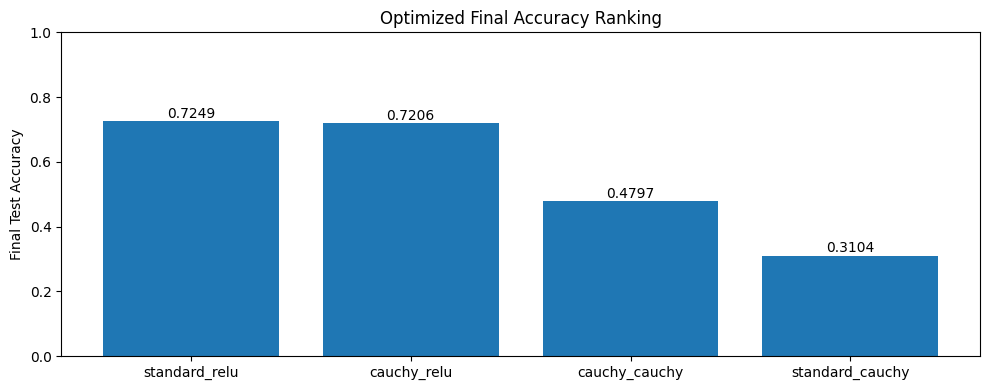

In [27]:
# ===== 优化版结果可视化与保存 =====
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
for exp_key, payload in results_optimized.items():
    y = payload["history"]["test_loss"]
    x = np.arange(1, len(y) + 1)
    plt.plot(x, y, label=exp_key)
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Optimized Test Loss Curves (4 Settings)")
plt.legend()

plt.subplot(1, 2, 2)
for exp_key, payload in results_optimized.items():
    y = payload["history"]["test_acc"]
    x = np.arange(1, len(y) + 1)
    plt.plot(x, y, label=exp_key)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Optimized Test Accuracy Curves (4 Settings)")
plt.legend()
plt.tight_layout()

ranked_opt = sorted(results_optimized.items(), key=lambda kv: kv[1]["final_test_acc"], reverse=True)
labels_opt = [k for k, _ in ranked_opt]
vals_opt = [v["final_test_acc"] for _, v in ranked_opt]

plt.figure(figsize=(10, 4))
plt.bar(labels_opt, vals_opt)
plt.ylim(0, 1.0)
plt.ylabel("Final Test Accuracy")
plt.title("Optimized Final Accuracy Ranking")
for i, v in enumerate(vals_opt):
    plt.text(i, v + 0.01, f"{v:.4f}", ha="center")
plt.tight_layout()

ckpt_path_opt = "./cauchy_cnn_cifar100_optimized_ablation.pt"
torch.save({
    "best_key": best_key_optimized,
    "best_model_state_dict": best_model_state_optimized,
    "results": results_optimized,
    "config": cfg_optimized,
    "classes": classes,
    "experiment_grid": experiment_grid,
    "debug_run": results_optimized[next(iter(results_optimized))]["debug_run"] if results_optimized else None,
}, ckpt_path_opt)
print(f"Saved optimized checkpoint to {ckpt_path_opt}")

In [28]:
# ===== 诊断：检查单卡顺序训练输出 =====
print("\n【单卡训练诊断】")
print(f"results_optimized keys: {list(results_optimized.keys())}")
print(f"实验数量: {len(results_optimized)} / {len(experiment_grid)}")
print(f"best_key_optimized: {best_key_optimized}")
print(f"best_acc_optimized: {best_acc_optimized}")

if "result_dir" in globals():
    print(f"结果目录: {result_dir}")

if len(results_optimized) != len(experiment_grid):
    print("\n⚠️ 警告：训练结果不完整，请查看结果目录中的输出文件。")
    if "result_dir" in globals():
        print("建议排查：")
        print(f"1. ls {result_dir}")
        print(f"2. 检查各个 *.json 文件是否存在")
else:
    print("\n✓ 4组实验均已完成并成功汇总。")
    print("各实验最终准确率：")
    for exp_key in sorted(results_optimized.keys()):
        print(f"  {exp_key:25s}: {results_optimized[exp_key]['final_test_acc']:.4f}")

if results_optimized:
    sample_key = next(iter(results_optimized.keys()))
    debug_flag = results_optimized[sample_key].get("debug_run", None)
    actual_epochs = len(results_optimized[sample_key]["history"]["test_acc"])
    print(f"debug_run: {debug_flag}, 实际epochs: {actual_epochs}")


【单卡训练诊断】
results_optimized keys: ['standard_relu', 'standard_cauchy', 'cauchy_relu', 'cauchy_cauchy']
实验数量: 4 / 4
best_key_optimized: standard_relu
best_acc_optimized: 0.7249
结果目录: tmp_parallel_results/single_gpu_run_1775098125

✓ 4组实验均已完成并成功汇总。
各实验最终准确率：
  cauchy_cauchy            : 0.4797
  cauchy_relu              : 0.7206
  standard_cauchy          : 0.3104
  standard_relu            : 0.7249
debug_run: False, 实际epochs: 100
